In [1]:
import pandas as pd
import re

# README.md 中与列名相关的内容片段
# 在实际应用中，如果 README.md 文件在工作区，可以直接读取该文件内容
# 此处为方便演示，直接将相关内容拷贝至此
readme_content = """
// REAL 数据段（字段1-10）
 ns2s(getT1(REAL)), ns2s(getT2(REAL)),
 ns2s(getT3(REAL)), ns2s(getT4(REAL)),
 ns2us(getT2T1(REAL)), ns2us(getT3T4(REAL)),
 ns2us(getOffset(REAL)), ns2us(getCalculatedOffset(REAL)),
 ns2us(getDelay(REAL)), ns2s(getT4T1(REAL)),

// RAW时钟数据段（字段11-20）
 ns2s(getT1(RAW)), ns2s(getT2(RAW)),
 ns2s(getT3(RAW)), ns2s(getT4(RAW)),
 ns2us(getT2T1(RAW)), ns2us(getT3T4(RAW)),
 ns2us(getOffset(RAW)), ns2us(getCalculatedOffset(RAW)),
 ns2us(getDelay(RAW)), ns2s(getT4T1(RAW)),

// 元数据段（字段21,22-25）
 seqNo,
 ns2us(t1RealKernel - t1RealApp), ns2us(t2RealApp - t2RealKernel),
 ns2us(t3RealKernel - t3RealApp), ns2us(t4RealApp - t4RealKernel)
// 其他字段（字段26-28）
remote_offset,t2-t1-remote_offset, remote_offset-(t3-t4)
"""

parsed_column_names = []
lines = readme_content.split('\n')
for line in lines:
    stripped_line = line.strip()
    # 检查行是否以列名定义开始
    if  not stripped_line.startswith("//") and stripped_line:
        # 按逗号分割并去除空白
        parts = [part.strip() for part in stripped_line.split(',')]
        for part in parts:
            if part:  # 确保部分不为空
                parsed_column_names.append(part)
# 日志文件路径
log_file_path = "../data/temperature_effects_0607/log0-original(低温).log"
temp_file_path = "../data/temperature_effects_0607/cpu_temp(低温).log"
try:
    # 读取日志文件，文件无表头，以空格分隔
    df = pd.read_csv(log_file_path, sep='\s+', header=None, engine='python')
    
    num_log_columns = df.shape[1]
    
    if num_log_columns > 0:
        if len(parsed_column_names) >= num_log_columns:
            df.columns = parsed_column_names[:num_log_columns]
            print(f"已将日志文件的前 {num_log_columns} 列赋值为从 README.md 解析的列名。")
        else:
            # 如果解析的列名不够，则只赋值已有的，其余列 pandas 会自动命名
            df.columns = parsed_column_names + [f'Unnamed_{i}' for i in range(num_log_columns - len(parsed_column_names))]
            print(f"警告: 日志文件有 {num_log_columns} 列, 但从 README.md 中只解析出 {len(parsed_column_names)} 个列名。")
            print(f"已将前 {len(parsed_column_names)} 列赋值，其余列自动命名。")

    print("\nDataFrame 前五行:")
    print(df.head())
    print("\nDataFrame 信息:")
    df.info()
    
    print(f"\n从 README.md 解析出的所有列名 (共 {len(parsed_column_names)} 个):")
    for i, name in enumerate(parsed_column_names):
        print(f"{i+1}. {name}")

except FileNotFoundError:
    print(f"错误: 文件 {log_file_path} 未找到。")
except pd.errors.EmptyDataError:
    print(f"错误: 文件 {log_file_path} 为空。")
except Exception as e:
    print(f"处理文件时发生错误: {e}")

# 读取 CPU 温度日志文件
try:
    # 假设 temp_file_path (在脚本前面已定义) 指向的文件格式为: 索引 温度 单位 (例如 "0 49.60 °C")
    # 使用 'names' 参数在读取时直接指定列名。
    # sep='\s+' 表示一个或多个空白字符作为分隔符。
    # engine='python' 是为了与您之前的代码保持一致，如果默认引擎工作正常，有时可以省略。
    temp_df = pd.read_csv(temp_file_path, 
                          sep='\s+', 
                          header=None, 
                          names=['original_index', 'temperature', 'unit'], 
                          engine='python')
    
    if not temp_df.empty:
        # pandas 通常会自动将 'temperature' 列（例如 '49.60'）解析为数值类型。
        # 如果需要显式转换并处理可能的非数值错误，可以取消注释以下行：
        # temp_df['temperature'] = pd.to_numeric(temp_df['temperature'], errors='coerce')
        # temp_df.dropna(subset=['temperature'], inplace=True) # 移除转换失败的行

        print(f"\nCPU 温度日志文件 ({temp_file_path}) 已成功读取。")
        print("列名已设置为: 'original_index', 'temperature', 'unit'")
        print("\nCPU 温度 DataFrame 前五行:")
        print(temp_df.head())
        print("\nCPU 温度 DataFrame 信息:")
        temp_df.info()
        
        # 示例：如果想将 'original_index' 列作为 DataFrame 的索引:
        # temp_df_indexed = temp_df.set_index('original_index')
        # print("\nCPU 温度 DataFrame (original_index 作为索引) 前五行:")
        # print(temp_df_indexed.head())
        
        # 示例：如果只需要温度数据作为一个 Pandas Series:
        # temperatures_series = temp_df['temperature']
        # print("\n提取的温度数据 (Series):")
        # print(temperatures_series.head())

    else:
        print(f"CPU 温度日志文件 {temp_file_path} 为空或未能正确解析。")

except FileNotFoundError:
    print(f"错误: 文件 {temp_file_path} 未找到。")
except pd.errors.EmptyDataError:
    print(f"错误: 文件 {temp_file_path} 为空。")
except Exception as e:
    print(f"处理 CPU 温度日志文件时发生错误: {e}")



已将日志文件的前 28 列赋值为从 README.md 解析的列名。

DataFrame 前五行:
   ns2s(getT1(REAL))  ns2s(getT2(REAL))  ns2s(getT3(REAL))  ns2s(getT4(REAL))  \
0       1.742663e+09       1.740173e+09       1.740173e+09       1.742663e+09   
1       1.742663e+09       1.740173e+09       1.740173e+09       1.742663e+09   
2       1.742663e+09       1.740173e+09       1.740173e+09       1.742663e+09   
3       1.742663e+09       1.740173e+09       1.740173e+09       1.742663e+09   
4       1.742663e+09       1.740173e+09       1.740173e+09       1.742663e+09   

   ns2us(getT2T1(REAL))  ns2us(getT3T4(REAL))  ns2us(getOffset(REAL))  \
0         -2.490137e+12         -2.490137e+12           -2.490137e+12   
1         -2.490137e+12         -2.490137e+12           -2.490137e+12   
2         -2.490137e+12         -2.490137e+12           -2.490137e+12   
3         -2.490137e+12         -2.490137e+12           -2.490137e+12   
4         -2.490137e+12         -2.490137e+12           -2.490137e+12   

   ns2us(getCalculatedO


提取的 RAW 时钟 T1, T2, T3, T4 数据:
T1: [184.635128927, 184.697694001, 184.760261686, 184.822827575, 184.885379834]... (共 19099 个数据)
T2: [491.899620632, 491.96218741, 492.024763391, 492.087313725, 492.149863317]... (共 19099 个数据)
T3: [491.899623447, 491.962190336, 492.024766614, 492.087316632, 492.149865965]... (共 19099 个数据)
T4: [184.635320464, 184.697892038, 184.760466019, 184.823013371, 184.88556076]... (共 19099 个数据)


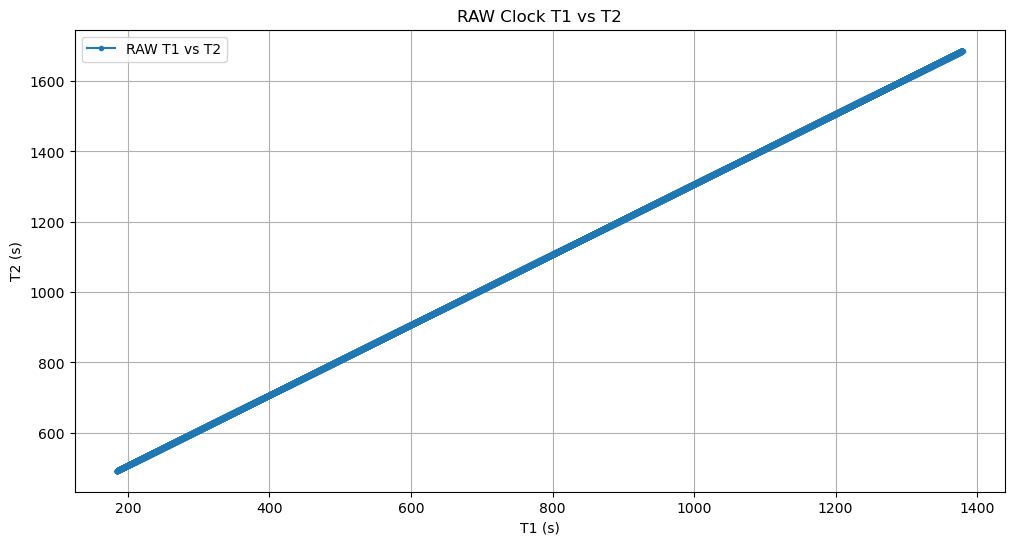


分段滑窗拟合的斜率:
Segment 1: Slope = 0.999998
Segment 11: Slope = 0.999999
Segment 21: Slope = 0.999999
Segment 31: Slope = 0.999999
Segment 41: Slope = 1.000000
Segment 51: Slope = 1.000000
Segment 61: Slope = 1.000000
Segment 71: Slope = 1.000000
Segment 81: Slope = 1.000000
Segment 91: Slope = 0.999999
Segment 101: Slope = 0.999999
Segment 111: Slope = 0.999999
Segment 121: Slope = 0.999999


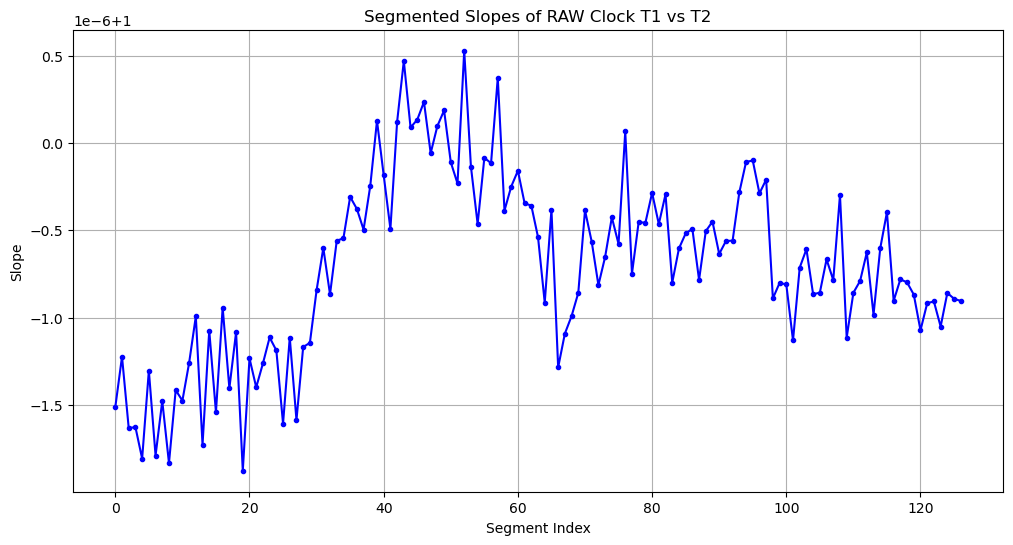

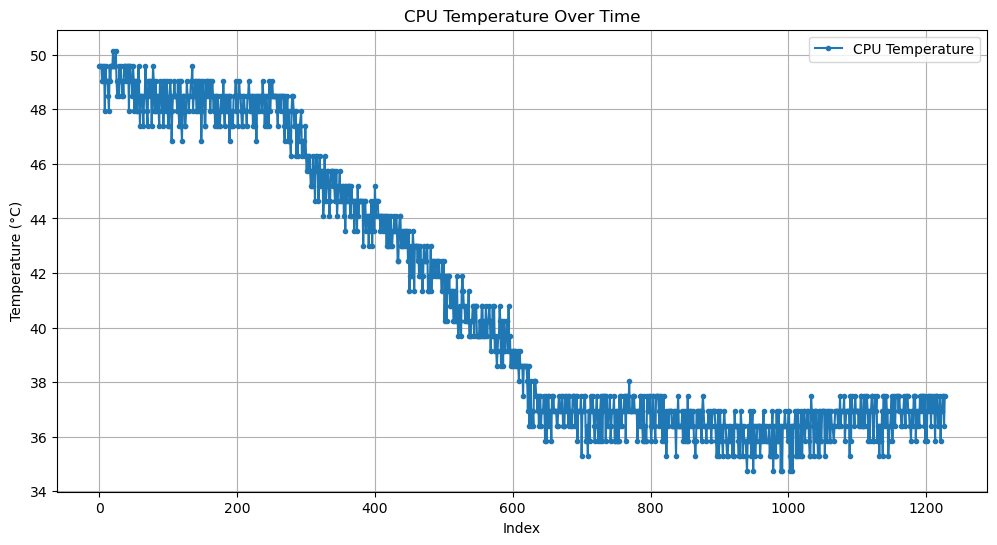

In [2]:
#提取RAW时钟T1,T2,T3,T4的数据
RAW_Time = []
for i in range(10, 14):
    if i < len(df.columns):
        RAW_Time.append(df.iloc[:, i].tolist())
    else:
        print(f"警告: 列索引 {i} 超出 DataFrame 的列范围。")
# 打印提取的 RAW 时钟数据
print("\n提取的 RAW 时钟 T1, T2, T3, T4 数据:")
for i, time_data in enumerate(RAW_Time, start=1):
    print(f"T{i}: {time_data[:5]}... (共 {len(time_data)} 个数据)")
#T2为Y，T1为X的数据图
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(RAW_Time[0], RAW_Time[1], 'o-', label='RAW T1 vs T2', markersize=3)
plt.title('RAW Clock T1 vs T2')
plt.xlabel('T1 (s)')
plt.ylabel('T2 (s)')
plt.grid()
plt.legend()
plt.show()
#分段滑窗拟合各段的斜率
import numpy as np
def segment_slope_fit(x, y, segment_length=1000):
    slopes = []
    for start in range(0, len(x) - segment_length + 1, segment_length):
        end = start + segment_length
        if end > len(x):
            break
        x_segment = x[start:end]
        y_segment = y[start:end]
        if len(x_segment) < 2 or len(y_segment) < 2:
            continue
        slope, _ = np.polyfit(x_segment, y_segment, 1)
        slopes.append(slope)
    return slopes
# 计算分段斜率
slopes = segment_slope_fit(RAW_Time[0], RAW_Time[1], segment_length=150)
# 打印分段斜率
print("\n分段滑窗拟合的斜率:")
for i, slope in enumerate(slopes):
    if i% 10 == 0:
        print(f"Segment {i + 1}: Slope = {slope:.6f}")
# 绘制分段斜率图
plt.figure(figsize=(12, 6))
plt.plot(slopes, marker='o', linestyle='-', color='b', markersize=3)
plt.title('Segmented Slopes of RAW Clock T1 vs T2')
plt.xlabel('Segment Index')
plt.ylabel('Slope')
plt.grid()
plt.show()

#将温度变化绘制出来
plt.figure(figsize=(12, 6))
plt.plot(temp_df['original_index'], temp_df['temperature'], 'o-', label='CPU Temperature', markersize=3)
plt.title('CPU Temperature Over Time')
plt.xlabel('Index')
plt.ylabel('Temperature (°C)')
plt.grid()
plt.legend()
plt.show()

估算的基础采样间隔 tau_0_system: 0.062560 s


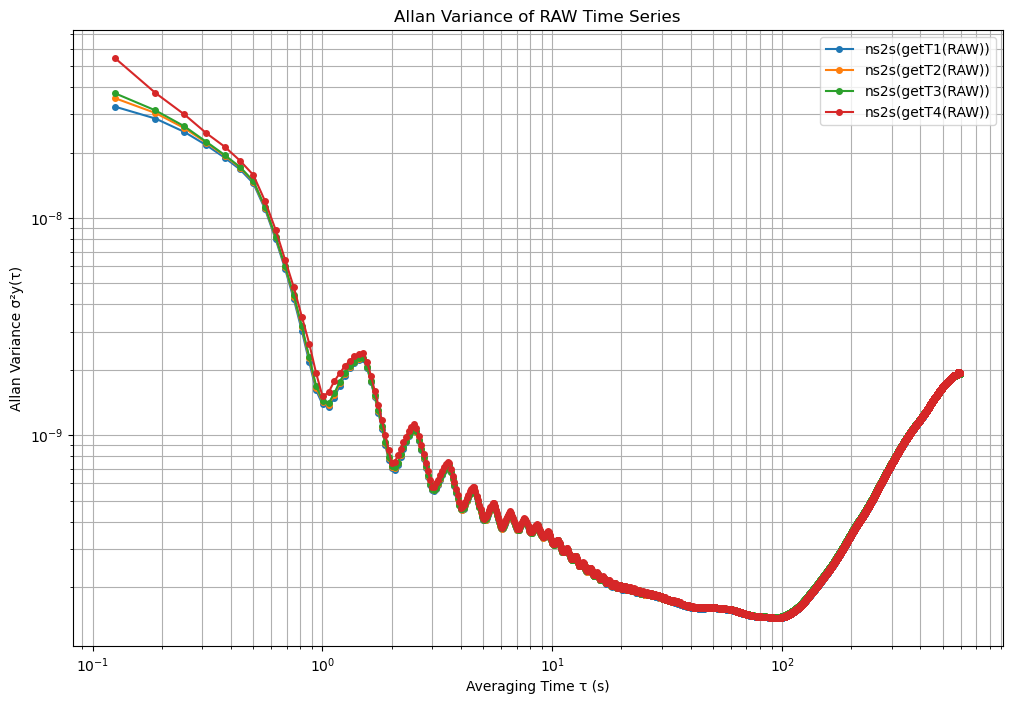

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_allan_variance(phi_series, m_values, tau_0_system):
    """
    计算给定相位（时间）序列的艾伦方差。

    参数:
    phi_series (array-like): 相位（时间）数据序列。
    m_values (array-like): 平均因子 m 的序列。
    tau_0_system (float): 基础采样间隔。

    返回:
    tuple: (taus, allan_variances)
           taus: 对应的平均时间 τ 的数组。
           allan_variances: 计算得到的艾伦方差数组。
    """
    N = len(phi_series)
    phi_series_np = np.array(phi_series, dtype=float) # 确保为浮点数数组
    
    allan_vars = []
    actual_taus = []

    for m in m_values:
        # 确保有足够的数据点进行计算 (N - 2m >= 1)
        if N <= 2 * m:
            # print(f"m={m} is too large for N={N}. Skipping remaining m values.")
            break 
        
        current_tau = m * tau_0_system
        if current_tau == 0: # 避免 tau 为零
            # print(f"Calculated tau is zero for m={m}, tau_0_system={tau_0_system}. Skipping.")
            continue

        # --- 向量化计算 sum_sq_diff 开始 ---
        # 原始的 phi_series[i] 项对应的切片
        phi_i = phi_series_np[0 : N - 2*m]
        # 原始的 phi_series[i+m] 项对应的切片
        phi_i_plus_m = phi_series_np[m : N - m]
        # 原始的 phi_series[i+2*m] 项对应的切片
        phi_i_plus_2m = phi_series_np[2*m : N]
        
        # 计算差分项 (x_{i+2m} - 2*x_{i+m} + x_i)
        diff_terms = phi_i_plus_2m - 2 * phi_i_plus_m + phi_i
        
        # 计算差分项的平方和
        sum_sq_diff = np.sum(diff_terms**2)
        # --- 向量化计算 sum_sq_diff 结束 ---
        
        # 艾伦方差公式
        # (N - 2 * m) 是求和中的项数
        variance = sum_sq_diff / (2 * (N - 2 * m) * (current_tau**2))
        
        allan_vars.append(variance)
        actual_taus.append(current_tau)
        
    return np.array(actual_taus), np.array(allan_vars)

# 假设 df 和 RAW_Time 变量已在之前的单元格中定义
# 假设 parsed_column_names 也已定义

# 1. 估算基础采样间隔 tau_0_system
# 使用 df 的第一列 (通常是 ns2s(getT1(REAL)))
try:
    if 'df' in globals() and not df.empty:
        # 确保第一列是数值类型并且已去除NaN
        time_column_for_tau0 = pd.to_numeric(df.iloc[:, 0], errors='coerce').dropna().values
        if len(time_column_for_tau0) > 1:
            diffs = np.diff(time_column_for_tau0)
            if np.all(diffs > 0): # 确保时间戳递增
                 tau_0_system = np.mean(diffs)
            else:
                print("警告: 用于估算 tau_0 的时间戳不完全递增，可能影响精度。使用绝对差值的平均值。")
                tau_0_system = np.mean(np.abs(diffs))
            if tau_0_system <= 0:
                print(f"警告: 估算的 tau_0_system ({tau_0_system}) 非正。将使用默认值 1.0。")
                tau_0_system = 1.0
        else:
            print("警告: df 第一列数据不足以估算 tau_0_system。将使用默认值 1.0。")
            tau_0_system = 1.0 # 默认值
    else:
        print("警告: DataFrame 'df' 未定义或为空。将使用默认 tau_0_system = 1.0。")
        tau_0_system = 1.0
except Exception as e:
    print(f"估算 tau_0_system 时出错: {e}。将使用默认值 1.0。")
    tau_0_system = 1.0

print(f"估算的基础采样间隔 tau_0_system: {tau_0_system:.6f} s")

# 2. 为 RAW_Time 中的每个序列计算并绘制艾伦方差
plt.figure(figsize=(12, 8))

# 获取 RAW_Time 列的标签
raw_time_labels = []
if 'parsed_column_names' in globals() and len(parsed_column_names) >= 14:
    raw_time_labels = [parsed_column_names[i] for i in range(10, 14)]
else:
    raw_time_labels = [f'RAW Time Series {i+1}' for i in range(4)] # Fallback labels

if 'RAW_Time' in globals() and len(RAW_Time) == 4:
    for i, series_data in enumerate(RAW_Time):
        if len(series_data) < 5: # 需要至少5个点来计算 m=2 的情况 (N-2m >= 1 => N-4 >=1 => N>=5)
            print(f"序列 '{raw_time_labels[i]}' 数据点过少 ({len(series_data)}个)，无法计算艾伦方差。")
            continue

        # 定义 m 值范围："区间长度从2 往上遍历"
        # m 最大可取 (N-1)//2，确保 N-2m >= 1
        max_m = (len(series_data) - 1) // 2
        if max_m < 2:
            print(f"序列 '{raw_time_labels[i]}' 数据点过少 ({len(series_data)}个)，无法为 m>=2 计算艾伦方差。")
            continue
        
        m_values = range(2, max_m + 1)
        
        taus, allan_variances = calculate_allan_variance(series_data, m_values, tau_0_system)
        
        # 过滤掉 NaN 或 inf 值，避免绘图错误
        valid_indices = np.isfinite(taus) & np.isfinite(allan_variances) & (allan_variances > 0) # 方差应为正
        taus_filtered = taus[valid_indices]
        allan_variances_filtered = allan_variances[valid_indices]

        if len(taus_filtered) > 0:
            plt.loglog(taus_filtered, allan_variances_filtered, marker='o', linestyle='-', label=raw_time_labels[i], markersize=4)
        else:
            print(f"序列 '{raw_time_labels[i]}' 未能计算出有效的艾伦方差值进行绘制。")

    plt.title('Allan Variance of RAW Time Series')
    plt.xlabel('Averaging Time τ (s)')
    plt.ylabel('Allan Variance σ²y(τ)')
    plt.grid(True, which="both", ls="-")
    plt.legend()
    plt.show()
else:
    print("错误: 'RAW_Time' 变量未定义或其长度不为4。")


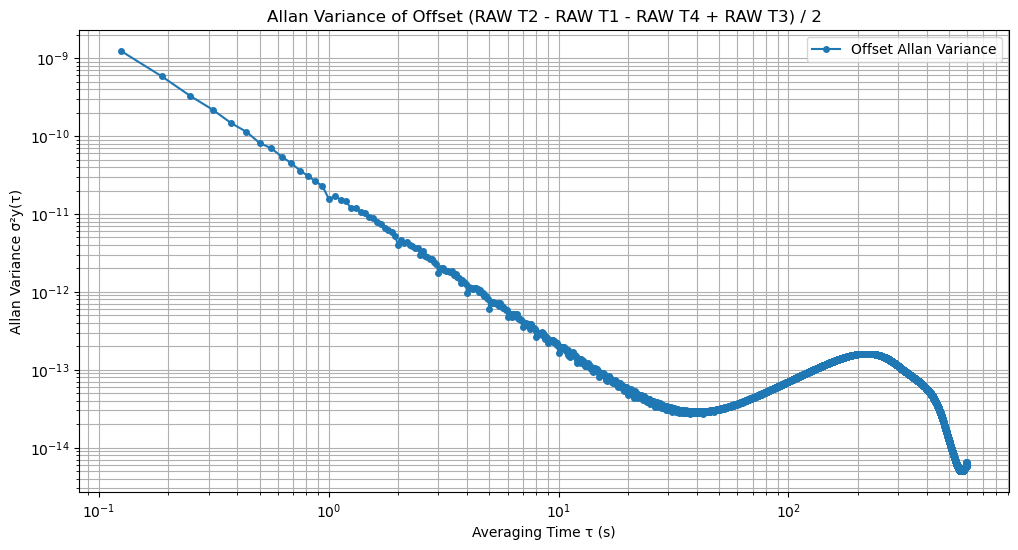


Offset Allan Variance - Tau vs. Number of Difference Terms (N-2m):
-----------------------------------------------------------------
Tau (s)              | Num Diff Terms (N-2m)    
-----------------------------------------------------------------
0.125120             | 19095                    
0.187680             | 19093                    
0.250240             | 19091                    
0.312800             | 19089                    
0.375360             | 19087                    
0.437920             | 19085                    
0.500480             | 19083                    
0.563040             | 19081                    
0.625600             | 19079                    
0.688160             | 19077                    
29.966252            | 18141                    
59.807383            | 17187                    
89.648515            | 16233                    
119.489647           | 15279                    
149.330779           | 14325                    
179.171910      

In [4]:
import matplotlib.pyplot as plt
import numpy as np # 如果您的数据（如 taus_offset）是 numpy 数组

def calculate_allan_variance(phi_series, m_values, tau_0_system):
    """
    计算给定相位（时间）序列的艾伦方差。

    参数:
    phi_series (array-like): 相位（时间）数据序列。
    m_values (array-like): 平均因子 m 的序列。
    tau_0_system (float): 基础采样间隔。

    返回:
    tuple: (taus, allan_variances, num_diff_terms)
           taus: 对应的平均时间 τ 的数组。
           allan_variances: 计算得到的艾伦方差数组。
           num_diff_terms: 用于计算每个方差值的差分项数量 (N-2m) 的数组。
    """
    N = len(phi_series)
    phi_series_np = np.array(phi_series, dtype=float) # 确保为浮点数数组
    
    allan_vars = []
    actual_taus = []
    num_diff_terms_list = [] # 新增：用于存储 N-2m 的列表

    for m in m_values:
        # 确保有足够的数据点进行计算 (N - 2m >= 1)
        if N <= 2 * m:
            break 
        
        current_tau = m * tau_0_system
        if current_tau == 0: 
            continue

        # --- 向量化计算 sum_sq_diff 开始 ---
        phi_i = phi_series_np[0 : N - 2*m]
        phi_i_plus_m = phi_series_np[m : N - m]
        phi_i_plus_2m = phi_series_np[2*m : N]
        
        diff_terms = phi_i_plus_2m - 2 * phi_i_plus_m + phi_i
        sum_sq_diff = np.sum(diff_terms**2)
        # --- 向量化计算 sum_sq_diff 结束 ---
        
        current_num_diff_terms = N - 2 * m # 计算当前m对应的差分项数量
        if current_num_diff_terms == 0: # 避免除以零，尽管前面的 N <= 2*m 应该已经处理了
            continue
            
        variance = sum_sq_diff / (2 * current_num_diff_terms * (current_tau**2))
        
        allan_vars.append(variance)
        actual_taus.append(current_tau)
        num_diff_terms_list.append(current_num_diff_terms) # 存储差分项数量
        
    return np.array(actual_taus), np.array(allan_vars), np.array(num_diff_terms_list) # 返回三个数组
offset = (np.array(RAW_Time[1]) - np.array(RAW_Time[0]) - (np.array(RAW_Time[3]) - np.array(RAW_Time[2]))) / 2

# 重新确定 m_values 范围，以 offset 序列的长度为准
N_offset = len(offset)
if N_offset > 4: # 确保至少可以计算 m=2 的情况
    max_m_offset = (N_offset - 1) // 2
    if max_m_offset >=2:
        m_values_offset = range(2, max_m_offset + 1)
    else:
        m_values_offset = [] # 如果数据太少，则 m_values 为空
else:
    m_values_offset = []

if not list(m_values_offset): # 检查 m_values_offset 是否为空
    print("Offset 数据太少，无法计算艾伦方差。")
    taus_offset = np.array([])
    allan_variances_offset = np.array([])
    num_terms_offset = np.array([])
else:
    #计算allan方差
    taus_offset, allan_variances_offset, num_terms_offset = calculate_allan_variance(offset, m_values_offset, tau_0_system)

# 绘制 offset 的艾伦方差
if len(taus_offset) > 0: # 确保有数据可绘制
    plt.figure(figsize=(12, 6))
    plt.loglog(taus_offset, allan_variances_offset, marker='o', linestyle='-', label='Offset Allan Variance', markersize=4)
    plt.title('Allan Variance of Offset (RAW T2 - RAW T1 - RAW T4 + RAW T3) / 2')
    plt.xlabel('Averaging Time τ (s)')
    plt.ylabel('Allan Variance σ²y(τ)')
    plt.grid(True, which="both", ls="-")
    plt.legend()
    plt.show()

    print("\nOffset Allan Variance - Tau vs. Number of Difference Terms (N-2m):")
    print("-----------------------------------------------------------------")
    print(f"{'Tau (s)':<20} | {'Num Diff Terms (N-2m)':<25}")
    print("-----------------------------------------------------------------")
    for i in range(len(taus_offset)):
        # 只打印部分数据以避免输出过长，例如每隔几个点打印一次，或者只打印最后几个点
        if i < 10 or i > len(taus_offset) - 11 or i % (max(1, len(taus_offset) // 20)) == 0 : # 打印开头、结尾和中间的一些点
             print(f"{taus_offset[i]:<20.6f} | {num_terms_offset[i]:<25}")
    if len(taus_offset) > 20 : # 如果点很多，提示一下
        print("... (中间部分数据已省略以减少输出) ...")
    print("-----------------------------------------------------------------")
else:
    print("未能计算出 Offset 的艾伦方差数据进行绘制。")



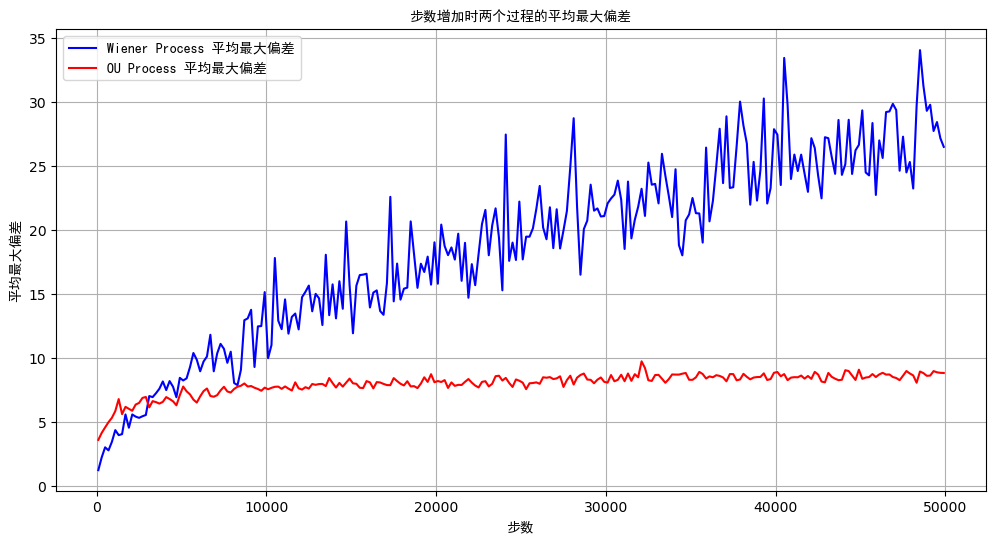

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_wiener_process(num_steps, step_size):
    steps = np.random.normal(loc=0, scale=step_size, size=num_steps)
    wiener_process = np.cumsum(steps)
    return wiener_process

def simulate_ou_process(num_steps, step_size, theta, mu):
    ou_process = np.zeros(num_steps)
    for i in range(1, num_steps):
        ou_process[i] = ou_process[i-1] + theta * (mu - ou_process[i-1])*step_size + np.random.normal(0, step_size**0.5)
    return ou_process

# 参数设置
step_size = 0.1
theta = 0.1
mu = 0.0
num_trials = 10  # 每个步数下的重复模拟次数
step_points = np.arange(100, 50001, 200)  # 步数取值

wiener_max_devs = []
ou_max_devs = []

for num_steps in step_points:
    wiener_devs = []
    ou_devs = []
    for _ in range(num_trials):
        wiener = simulate_wiener_process(num_steps, step_size)
        ou = simulate_ou_process(num_steps, step_size, theta, mu)
        wiener_devs.append(np.max(np.abs(wiener)))
        ou_devs.append(np.max(np.abs(ou)))
    wiener_max_devs.append(np.mean(wiener_devs))
    ou_max_devs.append(np.mean(ou_devs))

plt.figure(figsize=(12, 6))
plt.plot(step_points, wiener_max_devs, label='Wiener Process 平均最大偏差', color='blue')
plt.plot(step_points, ou_max_devs, label='OU Process 平均最大偏差', color='red')
plt.xlabel('步数', fontproperties='SimHei')
plt.ylabel('平均最大偏差', fontproperties='SimHei')
plt.title('步数增加时两个过程的平均最大偏差', fontproperties='SimHei')
plt.legend(prop={'family': 'SimHei'})
plt.grid()
plt.show()